In [ ]:

######## snakemake preamble start (automatically inserted, do not edit) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('results/ASVs_counts_normalized.tsv', "results/ASVs_euclidean_distance.tsv", "norm_counts_tab" = 'results/ASVs_counts_normalized.tsv' , 'distances_matrix' = "results/ASVs_euclidean_distance.tsv"),
    output = list('results/reports/plot_pcoa.pdf', "plot_pcoa" = 'results/reports/plot_pcoa.pdf'),
    params = list(),
    wildcards = list(),
    threads = 1,
    log = list(),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("pathvars" = list("data_initial" = 'data/initial', "data_raw" = 'data/raw', "samples" = 'data/raw/fastq', "samples_filter" = 'data/raw/fastq/filtered', "temp" = 'data/temp', "results" = 'results', "reports" = 'results/reports', "figures" = 'results/figures')),
    rule = 'BetaDiversity',
    bench_iteration = as.numeric(NA),
    scriptdir = '/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression/workflow/steps/03_alpha_beta/notebooks',
    source = function(...){
        old_wd <- getwd()
        on.exit(setwd(old_wd), add = TRUE)

        is_url <- grepl("^https?://", snakemake@scriptdir)
        file <- ifelse(is_url, file.path(snakemake@scriptdir, ...), ...)
        if (!is_url) setwd(snakemake@scriptdir)
        source(file)
    }
)
setwd('/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression');

######## snakemake preamble end #########


In [8]:
library(phyloseq); packageVersion('phyloseq')
library(ggplot2); packageVersion(('ggplot2'))
library(vegan); packageVersion(('vegan'))

[1] ‘1.54.0’

[1] ‘4.0.3’

[1] ‘2.7.3’

## Make Phyloseq object

In [18]:
norm_counts_tab <- read.csv(snakemake@input$norm_counts_tab,sep = "\t", row.names='X')
samples_info <- read.csv('data/initial/all_meta.csv', row.names='Run')[colnames(norm_counts_tab), ]
euc_dist <- dist(read.csv(snakemake@input$distances_matrix, sep='\t'))


counts_phy <- otu_table(norm_counts_tab, taxa_are_rows = T)
samples_info_phy <- sample_data(samples_info)

phy <- phyloseq(counts_phy, samples_info_phy)

Warning message in dist(read.csv(snakemake@input$distances_matrix, sep = "\t")):
“NAs introduced by coercion”


## Plot ordination using PCoA

In [19]:
pcoa <- ordinate(phy, method = "MDS", distance = "euclidean")
eigen_vals <- pcoa$values$Eigenvalues

In [20]:
samples_groups_names <- "bd_phq9_any_dep"

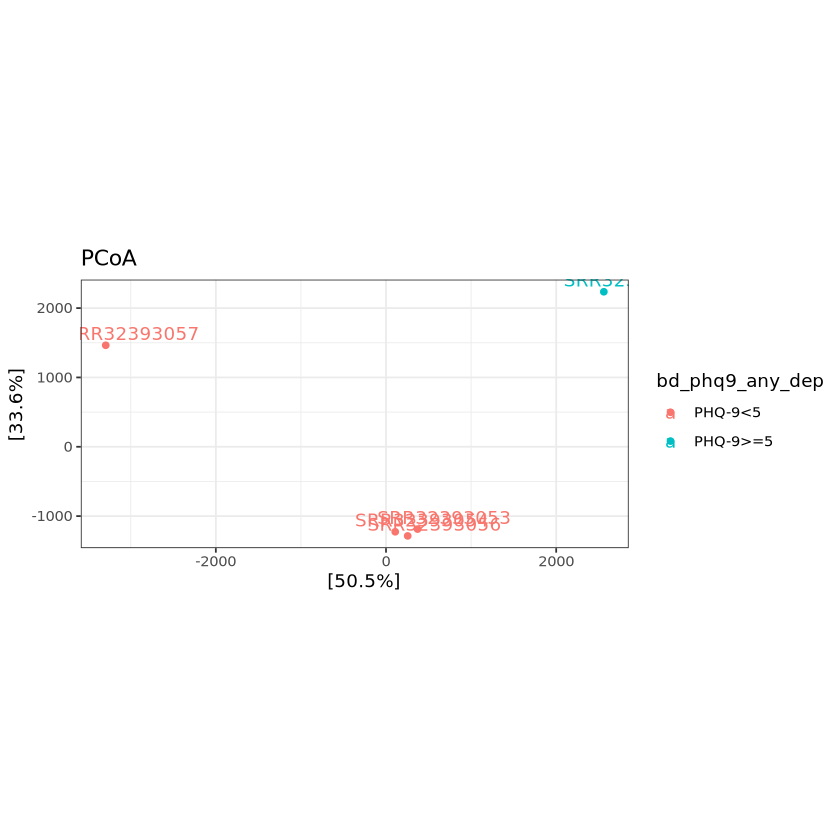

In [ ]:
source("workflow/steps/03_alpha_beta/scripts/ploting/pcoa.R")

plot_pcoa(phy, pcoa, samples_info, eigen_vals, samples_groups_names, snakemake@output$plot_pcoa)

### Betadisper

In [27]:
anova(betadisper(euc_dist, samples_info[[samples_groups_names]]))

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,9701277,9701277,1.561729,0.3000275
Residuals,3,18635646,6211882,NA,NA


In [44]:
metadf <- as.data.frame(as.matrix(phy@sam_data))
permanova_result <- adonis2(euc_dist ~ bd_phq9_any_dep, data = metadf,by='term',parallel = 30)
permanova_result

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.



,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bd_phq9_any_dep,1,39487531,0.3937096,1.948124,0.4
Residual,3,60808553,0.6062904,NA,NA
Total,4,100296084,1.0000000,NA,NA


## Chao1, Shannon, Simpson

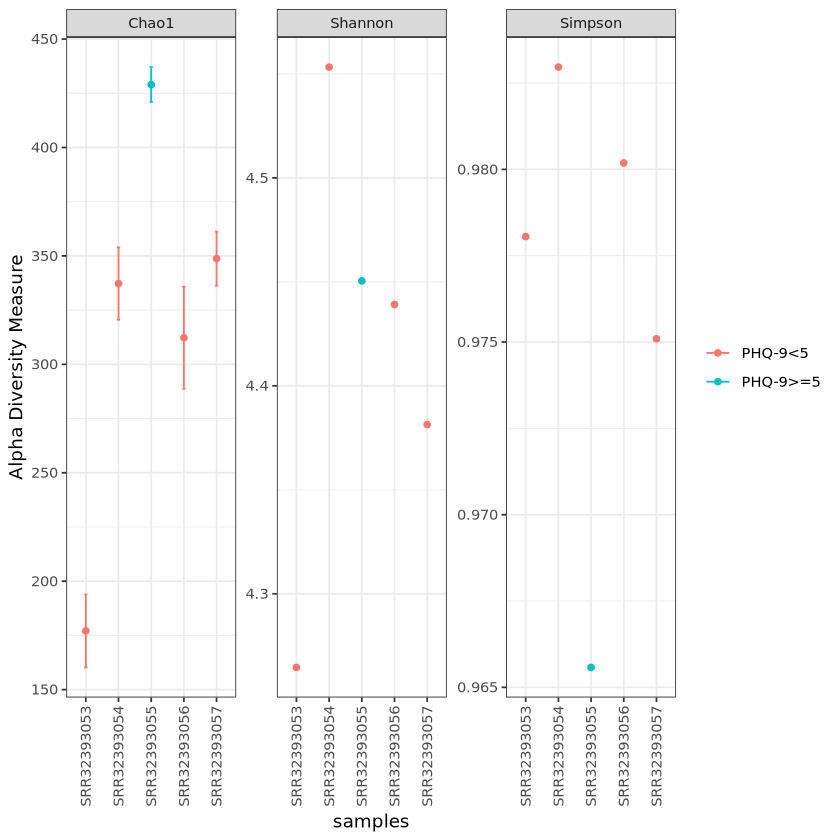

In [16]:
plot_richness(phy, color=samples_groups_names, measures = c("Chao1", "Shannon", "Simpson")) +
    theme_bw() + 
    theme(
        legend.title = element_blank(), 
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)
    )